In [1]:
# ============================================================
# 1. YOLO 폴더 구조 생성 코드
# Re:af AI - YOLO lesion detector dataset structure
# ============================================================

from pathlib import Path

# 프로젝트 기본 경로
BASE_DIR = Path("/home/harry/Re_leaf_Project")

# YOLO 병반 탐지용 데이터셋 폴더
YOLO_DATASET_DIR = BASE_DIR / "reaf_yolo_lesion_dataset"

# 생성할 폴더 구조
dirs = [
    YOLO_DATASET_DIR / "images" / "train",
    YOLO_DATASET_DIR / "images" / "val",
    YOLO_DATASET_DIR / "images" / "test",

    YOLO_DATASET_DIR / "labels" / "train",
    YOLO_DATASET_DIR / "labels" / "val",
    YOLO_DATASET_DIR / "labels" / "test",
]

# 폴더 생성
for d in dirs:
    d.mkdir(parents=True, exist_ok=True)

print("YOLO 폴더 구조 생성 완료!")
print(f"생성 위치: {YOLO_DATASET_DIR}")

# 생성된 폴더 확인
for d in dirs:
    print(d)

YOLO 폴더 구조 생성 완료!
생성 위치: /home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset
/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/images/train
/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/images/val
/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/images/test
/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/labels/train
/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/labels/val
/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/labels/test


In [2]:
# ============================================================
# 2. labelImg 설치 및 실행 코드
# PyTorch/YOLOv8 작업용 라벨링 도구
# ============================================================

# 터미널 또는 주피터 셀에서 실행
!pip install labelImg

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 68.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 45.8 MB/s  0:00:01 eta 0:00:01
  Created wheel for labelImg: filename=labelimg-1.8.6-py2.py3-none-any.whl size=261612 sha256=15d84e3260a3c06d1ffc1df3bebee76c7cf90198208a7e49f20b9ef77cd85ef3
  Stored in directory: /home/harry/.cache/pip/wheels/79/90/db/e0700438d3647c0209061d77992c901d3c786a56fec574ac86
Successfully built labelImg
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [labelImg]2/4 [pyqt5]


In [5]:
!labelImg

qt.qpa.plugin: Could not load the Qt platform plugin "xcb" in "" even though it was found.
This application failed to start because no Qt platform plugin could be initialized. Reinstalling the application may fix this problem.

Available platform plugins are: eglfs, linuxfb, minimal, minimalegl, offscreen, vnc, wayland-egl, wayland, wayland-xcomposite-egl, wayland-xcomposite-glx, webgl, xcb.



In [6]:
# ============================================================
# real_crop_38cls_quality_crawl
# → YOLO train 이미지 폴더로 전체 복사
# ============================================================

from pathlib import Path
import shutil

# 원본 폴더
SOURCE_DIR = Path("/home/harry/Re_leaf_Project/real_crop_38cls_quality_crawl")

# YOLO train 이미지 폴더
TARGET_DIR = Path("/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/images/train")

TARGET_DIR.mkdir(parents=True, exist_ok=True)

# 이미지 확장자
IMAGE_EXTS = [".jpg", ".jpeg", ".png"]

# 전체 이미지 수집
all_images = []

for ext in IMAGE_EXTS:
    all_images.extend(SOURCE_DIR.rglob(f"*{ext}"))

print(f"발견된 이미지 수: {len(all_images)}")

# 복사
for img_path in all_images:
    shutil.copy(img_path, TARGET_DIR / img_path.name)

print("전체 복사 완료!")
print("저장 위치:", TARGET_DIR)

발견된 이미지 수: 717
전체 복사 완료!
저장 위치: /home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/images/train


In [7]:
from pathlib import Path

train_dir = Path("/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/images/train")

files = list(train_dir.glob("*"))

print("파일 개수:", len(files))

for f in files[:10]:
    print(f.name)

파일 개수: 168
000030.jpg
000167.jpg
000031.jpg
000136.jpg
000061.jpg
000134.jpg
000183.jpg
000049.jpg
000094.jpg
000115.jpg


In [8]:
from pathlib import Path
import shutil

SOURCE_DIR = Path("/home/harry/Re_leaf_Project/real_crop_38cls_quality_crawl")
TARGET_DIR = Path("/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/images/train")

TARGET_DIR.mkdir(parents=True, exist_ok=True)

# 기존 train 이미지 비우기
for f in TARGET_DIR.glob("*"):
    f.unlink()

IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]

all_images = []

for img_path in SOURCE_DIR.rglob("*"):
    if img_path.suffix in IMAGE_EXTS:
        # healthy 제외
        if "healthy" not in str(img_path).lower():
            all_images.append(img_path)

print("복사 대상 이미지 수:", len(all_images))

for img_path in all_images:
    class_name = img_path.parent.name
    new_name = f"{class_name}__{img_path.name}"
    shutil.copy(img_path, TARGET_DIR / new_name)

copied_files = list(TARGET_DIR.glob("*"))
print("최종 복사된 이미지 수:", len(copied_files))

for f in copied_files[:10]:
    print(f.name)

복사 대상 이미지 수: 535
최종 복사된 이미지 수: 535
Corn_(maize)___Northern_Leaf_Blight__000156.jpg
Corn_(maize)___Common_rust___000006.jpg
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)__000036.jpg
Strawberry___Leaf_scorch__000014.jpg
Cherry_(including_sour)___Powdery_mildew__000011.jpg
Grape___Black_rot__000060.jpg
Corn_(maize)___Common_rust___000076.jpg
Tomato___Tomato_Yellow_Leaf_Curl_Virus__000047.jpg
Grape___Black_rot__000055.jpg
Potato___Early_blight__000068.jpg


In [9]:
# ============================================================
# WSL Ubuntu → Windows train 폴더로 복사
# 파일명 충돌 방지 버전
# healthy 제외
# ============================================================

from pathlib import Path
import shutil

# 원본 real image dataset
SOURCE_DIR = Path("/home/harry/Re_leaf_Project/real_crop_38cls_quality_crawl")

# Windows train 폴더
TARGET_DIR = Path("/mnt/c/Re_leaf_Project/reaf_yolo_lesion_dataset/images/train")

TARGET_DIR.mkdir(parents=True, exist_ok=True)

# 기존 파일 삭제
for f in TARGET_DIR.glob("*"):
    if f.is_file():
        f.unlink()

IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]

all_images = []

for img_path in SOURCE_DIR.rglob("*"):

    if img_path.suffix in IMAGE_EXTS:

        # healthy 제외
        if "healthy" not in str(img_path).lower():

            all_images.append(img_path)

print("복사 대상 이미지 수:", len(all_images))

# 복사
for img_path in all_images:

    class_name = img_path.parent.name

    # 파일명 충돌 방지
    new_name = f"{class_name}__{img_path.name}"

    shutil.copy(img_path, TARGET_DIR / new_name)

print("복사 완료!")

# 최종 확인
copied_files = list(TARGET_DIR.glob("*"))

print("최종 복사된 파일 수:", len(copied_files))

복사 대상 이미지 수: 535
복사 완료!
최종 복사된 파일 수: 535


In [10]:
# ============================================================
# 3-2. 이미지/라벨 개수 확인
# ============================================================

from pathlib import Path

DATASET_DIR = Path("/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset")

image_dir = DATASET_DIR / "images" / "train"
label_dir = DATASET_DIR / "labels" / "train"

image_files = sorted(list(image_dir.glob("*")))
label_files = sorted(list(label_dir.glob("*.txt")))

print("train 이미지 수:", len(image_files))
print("train 라벨 수:", len(label_files))

print("\n이미지 예시:")
for f in image_files[:5]:
    print(f.name)

print("\n라벨 예시:")
for f in label_files[:5]:
    print(f.name)

train 이미지 수: 535
train 라벨 수: 120

이미지 예시:
Apple___Apple_scab__000003.jpg
Apple___Apple_scab__000006.jpg
Apple___Apple_scab__000015.jpg
Apple___Apple_scab__000016.jpg
Apple___Apple_scab__000017.jpg

라벨 예시:
Apple___Apple_scab__000003.txt
Apple___Apple_scab__000006.txt
Apple___Apple_scab__000015.txt
Apple___Apple_scab__000016.txt
Apple___Apple_scab__000017.txt


In [11]:
# ============================================================
# 3-3. 이미지와 라벨 이름 매칭 확인
# ============================================================

image_stems = {f.stem for f in image_files}
label_stems = {f.stem for f in label_files}

matched = image_stems & label_stems
missing_labels = image_stems - label_stems
extra_labels = label_stems - image_stems

print("매칭된 이미지/라벨 수:", len(matched))
print("라벨 없는 이미지 수:", len(missing_labels))
print("이미지 없는 라벨 수:", len(extra_labels))

print("\n라벨 없는 이미지 예시:")
for x in list(missing_labels)[:10]:
    print(x)

print("\n이미지 없는 라벨 예시:")
for x in list(extra_labels)[:10]:
    print(x)

매칭된 이미지/라벨 수: 120
라벨 없는 이미지 수: 415
이미지 없는 라벨 수: 0

라벨 없는 이미지 예시:
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot__000154
Tomato___Septoria_leaf_spot__000112
Tomato___Septoria_leaf_spot__000040
Corn_(maize)___Common_rust___000026
Tomato___Tomato_mosaic_virus__000030
Pepper,_bell___Bacterial_spot__000031
Pepper,_bell___Bacterial_spot__000038
Strawberry___Leaf_scorch__000093
Tomato___Septoria_leaf_spot__000015
Tomato___Early_blight__000038

이미지 없는 라벨 예시:


In [12]:
# ============================================================
# 3-4. lesion 단일 클래스 data.yaml 생성
# ============================================================

from pathlib import Path

DATASET_DIR = Path("/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset")
yaml_path = DATASET_DIR / "lesion_data.yaml"

yaml_text = f"""
path: {DATASET_DIR}
train: images/train
val: images/train

names:
  0: lesion
"""

with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_text.strip())

print("yaml 생성 완료:")
print(yaml_path)

print("\n--- yaml 내용 ---")
print(yaml_text)

yaml 생성 완료:
/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/lesion_data.yaml

--- yaml 내용 ---

path: /home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset
train: images/train
val: images/train

names:
  0: lesion



In [13]:
# ============================================================
# 4-1. YOLOv8 설치
# ============================================================

!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.7/828.7 kB 40.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 96.3 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ultralytics] [ultralytics]


In [14]:
# ============================================================
# 4-2. YOLOv8 학습 시작
# ============================================================

from ultralytics import YOLO

yaml_path = "/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/lesion_data.yaml"

# YOLOv8 nano 모델 사용
model = YOLO("yolov8n.pt")

results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=8,
    device=0,
    project="/home/harry/Re_leaf_Project/yolo_runs",
    name="reaf_lesion_yolov8n_120labels",
    exist_ok=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/harry/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.49 🚀 Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/lesion_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, free

In [15]:
# ============================================================
# 5-1. 학습된 YOLO 모델 로드
# ============================================================

from ultralytics import YOLO
from pathlib import Path
import cv2

YOLO_MODEL_PATH = Path("/home/harry/Re_leaf_Project/yolo_runs/reaf_lesion_yolov8n_120labels/weights/best.pt")

model = YOLO(str(YOLO_MODEL_PATH))

print("YOLO 모델 로드 완료:")
print(YOLO_MODEL_PATH)

YOLO 모델 로드 완료:
/home/harry/Re_leaf_Project/yolo_runs/reaf_lesion_yolov8n_120labels/weights/best.pt


In [16]:
# ============================================================
# 5-2. inference 대상 이미지 폴더 / crop 저장 폴더 설정
# ============================================================

TEST_IMAGE_DIR = Path("/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/images/train")

CROP_SAVE_DIR = Path("/home/harry/Re_leaf_Project/yolo_lesion_crops")
CROP_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("테스트 이미지 폴더:", TEST_IMAGE_DIR)
print("Crop 저장 폴더:", CROP_SAVE_DIR)

테스트 이미지 폴더: /home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/images/train
Crop 저장 폴더: /home/harry/Re_leaf_Project/yolo_lesion_crops


In [17]:
# ============================================================
# 5-3. YOLO inference 후 병반 crop 저장
# ============================================================

CONF_THRES = 0.25

image_paths = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    image_paths.extend(TEST_IMAGE_DIR.glob(ext))

print("inference 대상 이미지 수:", len(image_paths))

saved_count = 0
no_detect_count = 0

for img_path in image_paths:
    img = cv2.imread(str(img_path))

    if img is None:
        print("이미지 로드 실패:", img_path)
        continue

    results = model.predict(
        source=str(img_path),
        conf=CONF_THRES,
        imgsz=640,
        verbose=False
    )

    boxes = results[0].boxes

    if boxes is None or len(boxes) == 0:
        no_detect_count += 1
        continue

    for idx, box in enumerate(boxes):
        # xyxy 좌표
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

        # 이미지 범위 밖으로 나가지 않게 보정
        h, w = img.shape[:2]
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(w, x2)
        y2 = min(h, y2)

        crop = img[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        save_name = f"{img_path.stem}_crop{idx+1}.jpg"
        save_path = CROP_SAVE_DIR / save_name

        cv2.imwrite(str(save_path), crop)
        saved_count += 1

print("crop 저장 완료!")
print("저장된 crop 수:", saved_count)
print("탐지 실패 이미지 수:", no_detect_count)
print("저장 위치:", CROP_SAVE_DIR)

inference 대상 이미지 수: 535
crop 저장 완료!
저장된 crop 수: 60
탐지 실패 이미지 수: 511
저장 위치: /home/harry/Re_leaf_Project/yolo_lesion_crops


In [18]:
# ============================================================
# 5-4. 저장된 crop 이미지 확인
# ============================================================

import matplotlib.pyplot as plt
import random
import cv2

crop_paths = list(CROP_SAVE_DIR.glob("*.jpg"))

print("crop 이미지 수:", len(crop_paths))

sample_paths = random.sample(crop_paths, min(6, len(crop_paths)))

for p in sample_paths:
    img = cv2.imread(str(p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(p.name)
    plt.axis("off")
    plt.show()

crop 이미지 수: 60


<Figure size 300x300 with 1 Axes>

<Figure size 300x300 with 1 Axes>

<Figure size 300x300 with 1 Axes>

<Figure size 300x300 with 1 Axes>

<Figure size 300x300 with 1 Axes>

<Figure size 300x300 with 1 Axes>

In [20]:
from pathlib import Path

crop_dir = Path("/home/harry/Re_leaf_Project/yolo_lesion_crops")

crop_files = list(crop_dir.glob("*.jpg"))

print("crop 파일 개수:", len(crop_files))

for f in crop_files[:10]:
    print(f.name)

crop 파일 개수: 60
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot__000049_crop10.jpg
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot__000049_crop11.jpg
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot__000039_crop6.jpg
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot__000040_crop1.jpg
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot__000049_crop1.jpg
Apple___Cedar_apple_rust__000092_crop1.jpg
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot__000049_crop12.jpg
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot__000049_crop5.jpg
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot__000039_crop4.jpg
Apple___Cedar_apple_rust__000031_crop1.jpg


In [21]:
from PIL import Image
import matplotlib.pyplot as plt
import random

crop_files = list(crop_dir.glob("*.jpg"))

print("crop 개수:", len(crop_files))

sample = random.choice(crop_files)

print("선택된 파일:", sample)

img = Image.open(sample)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

crop 개수: 60
선택된 파일: /home/harry/Re_leaf_Project/yolo_lesion_crops/Apple___Cedar_apple_rust__000173_crop1.jpg


<Figure size 500x500 with 1 Axes>

In [22]:
# ============================================================
# 라벨 txt 개수 / 실제 라벨 있는 파일 개수 확인
# ============================================================

from pathlib import Path

DATASET_DIR = Path("/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset")

label_dir = DATASET_DIR / "labels" / "train"
image_dir = DATASET_DIR / "images" / "train"

label_files = list(label_dir.glob("*.txt"))
image_files = list(image_dir.glob("*"))

print("전체 이미지 수:", len(image_files))
print("라벨 txt 수:", len(label_files))

non_empty_labels = []

for f in label_files:
    if f.read_text().strip():
        non_empty_labels.append(f)

print("내용 있는 라벨 txt 수:", len(non_empty_labels))

전체 이미지 수: 535
라벨 txt 수: 120
내용 있는 라벨 txt 수: 120


In [23]:
# ============================================================
# conf 낮춰서 다시 crop 저장
# ============================================================

import cv2
import shutil
from pathlib import Path

CONF_THRES = 0.05

TEST_IMAGE_DIR = Path("/home/harry/Re_leaf_Project/reaf_yolo_lesion_dataset/images/train")
CROP_SAVE_DIR = Path("/home/harry/Re_leaf_Project/yolo_lesion_crops_conf005")

if CROP_SAVE_DIR.exists():
    shutil.rmtree(CROP_SAVE_DIR)

CROP_SAVE_DIR.mkdir(parents=True, exist_ok=True)

image_paths = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    image_paths.extend(TEST_IMAGE_DIR.glob(ext))

saved_count = 0
no_detect_count = 0

for img_path in image_paths:
    img = cv2.imread(str(img_path))

    results = model.predict(
        source=str(img_path),
        conf=CONF_THRES,
        imgsz=640,
        verbose=False
    )

    boxes = results[0].boxes

    if boxes is None or len(boxes) == 0:
        no_detect_count += 1
        continue

    h, w = img.shape[:2]

    for idx, box in enumerate(boxes):
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(w, x2)
        y2 = min(h, y2)

        crop = img[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        save_name = f"{img_path.stem}_crop{idx+1}.jpg"
        save_path = CROP_SAVE_DIR / save_name

        cv2.imwrite(str(save_path), crop)
        saved_count += 1

print("저장된 crop 수:", saved_count)
print("탐지 실패 이미지 수:", no_detect_count)
print("저장 위치:", CROP_SAVE_DIR)

저장된 crop 수: 504
탐지 실패 이미지 수: 436
저장 위치: /home/harry/Re_leaf_Project/yolo_lesion_crops_conf005


In [24]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

CROP_SAVE_DIR = Path("/home/harry/Re_leaf_Project/yolo_lesion_crops_conf005")

crop_files = list(CROP_SAVE_DIR.glob("*.jpg"))
print("crop 개수:", len(crop_files))

sample_paths = random.sample(crop_files, min(20, len(crop_files)))

for p in sample_paths:
    img = Image.open(p)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(p.name, fontsize=8)
    plt.axis("off")
    plt.show()

crop 개수: 504


<Figure size 300x300 with 1 Axes>

<Figure size 300x300 with 1 Axes>

<Figure size 300x300 with 1 Axes>

<Figure size 300x300 with 1 Axes>

...

<Figure size 300x300 with 1 Axes>

<Figure size 300x300 with 1 Axes>

<Figure size 300x300 with 1 Axes>

<Figure size 300x300 with 1 Axes>

<Figure size 300x300 with 1 Axes>

In [25]:
%matplotlib inline

crop 개수: 504
선택 파일: Apple___Cedar_apple_rust__000070_crop4.jpg


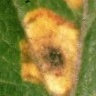

In [26]:
from IPython.display import display
from PIL import Image
from pathlib import Path
import random

CROP_SAVE_DIR = Path("/home/harry/Re_leaf_Project/yolo_lesion_crops_conf005")

crop_files = list(CROP_SAVE_DIR.glob("*.jpg"))
print("crop 개수:", len(crop_files))

sample = random.choice(crop_files)
print("선택 파일:", sample.name)

display(Image.open(sample))

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot__000039_crop25.jpg


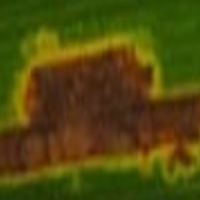

Apple___Cedar_apple_rust__000007_crop17.jpg


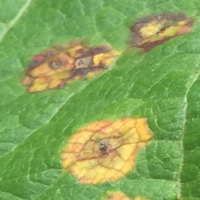

Apple___Black_rot__000143_crop10.jpg


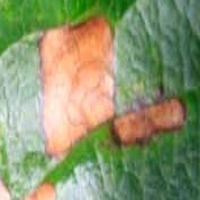

Apple___Cedar_apple_rust__000007_crop9.jpg


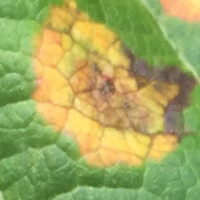

Apple___Apple_scab__000158_crop1.jpg


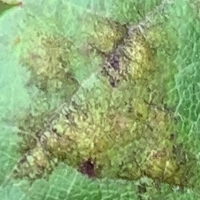

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot__000049_crop24.jpg


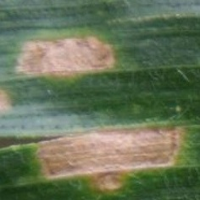

Apple___Cedar_apple_rust__000173_crop5.jpg


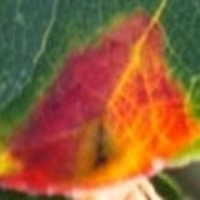

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot__000122_crop5.jpg


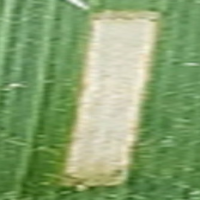

Apple___Apple_scab__000003_crop4.jpg


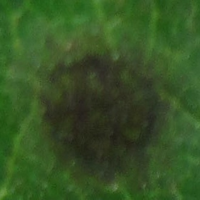

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot__000122_crop7.jpg


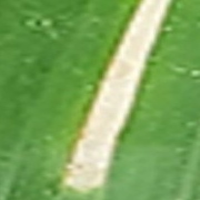

In [27]:
from IPython.display import display
from PIL import Image
import random

sample_paths = random.sample(crop_files, min(10, len(crop_files)))

for p in sample_paths:
    print(p.name)
    display(Image.open(p).resize((200, 200)))

In [28]:
# ============================================================
# 6-1. ConvNeXt 모델 로드 준비
# ============================================================

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from pathlib import Path
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 device:", device)

사용 device: cuda


In [30]:
# ============================================================
# 6-2. class_names 로드
# ============================================================

CLASS_NAMES_PATH = Path("/home/harry/Re_leaf_Project/class_names_38cls_convnext.json")

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = json.load(f)

print("클래스 수:", len(class_names))
print(class_names[:5])

클래스 수: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [31]:
# ============================================================
# 6-3. ConvNeXt Tiny 모델 구조 생성
# ============================================================

NUM_CLASSES = len(class_names)

convnext_model = models.convnext_tiny(weights=None)

# 마지막 classifier 교체
in_features = convnext_model.classifier[2].in_features
convnext_model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)

convnext_model = convnext_model.to(device)

print("ConvNeXt Tiny 모델 생성 완료")

ConvNeXt Tiny 모델 생성 완료


In [32]:
# ============================================================
# 6-4. 학습된 ConvNeXt weight 로드
# ============================================================

CONVNEXT_MODEL_PATH = Path("/home/harry/Re_leaf_Project/cp_convnext_tiny_38realmix_pvprep30_realprep_finetuned.pth")

state_dict = torch.load(CONVNEXT_MODEL_PATH, map_location=device)
convnext_model.load_state_dict(state_dict)

convnext_model.eval()

print("ConvNeXt weight 로드 완료:")
print(CONVNEXT_MODEL_PATH)

/tmp/ipykernel_3120/683523280.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(CONVNEXT_MODEL_PATH, map_location=device)


ConvNeXt weight 로드 완료:
/home/harry/Re_leaf_Project/cp_convnext_tiny_38realmix_pvprep30_realprep_finetuned.pth


In [33]:
# ============================================================
# 6-5. ConvNeXt 입력 전처리 정의
# ============================================================

convnext_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [39]:
# ============================================================
# 6-6. ConvNeXt 원본 이미지 전체 예측 함수
# ============================================================

def predict_full_image_convnext(image_path, topk=5):
    image = Image.open(image_path).convert("RGB")
    input_tensor = convnext_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = convnext_model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]

    top_probs, top_indices = torch.topk(probs, k=topk)

    results = []

    for prob, idx in zip(top_probs, top_indices):
        results.append({
            "class_name": class_names[idx.item()],
            "confidence": float(prob.item())
        })

    return results

In [43]:
# ============================================================
# 6-7. 방식 A: YOLO 병반 유무 필터 + ConvNeXt 전체 이미지 분류
# ============================================================

from ultralytics import YOLO
from pathlib import Path
from PIL import Image
from IPython.display import display

YOLO_MODEL_PATH = Path("/home/harry/Re_leaf_Project/yolo_runs/reaf_lesion_yolov8n_120labels/weights/best.pt")

yolo_model = YOLO(str(YOLO_MODEL_PATH))

YOLO_CONF_THRES = 0.01
CONVNEXT_TOPK = 5


def predict_reaf_mode_a(image_path, show=True):
    image_path = Path(image_path)

    # 1. YOLO 병반 유무 판단
    yolo_results = yolo_model.predict(
        source=str(image_path),
        conf=YOLO_CONF_THRES,
        imgsz=640,
        verbose=False
    )

    boxes = yolo_results[0].boxes

    if boxes is None or len(boxes) == 0:
        yolo_detected = False
        yolo_max_conf = 0.0
    else:
        yolo_detected = True
        yolo_max_conf = float(boxes.conf.max().cpu().item())

    # 2. ConvNeXt는 원본 전체 이미지를 보고 분류
    convnext_preds = predict_full_image_convnext(
        image_path=image_path,
        topk=CONVNEXT_TOPK
    )

    top1_class = convnext_preds[0]["class_name"]
    top1_conf = convnext_preds[0]["confidence"]

    # 3. 최종 판단 로직
    if yolo_detected:
        final_decision = "병반 탐지됨 → ConvNeXt 질병 분류 결과 사용"
    else:
        if "healthy" in top1_class.lower():
            final_decision = "병반 미탐지 + ConvNeXt healthy → 건강 가능성 높음"
        else:
            final_decision = "병반 미탐지 + ConvNeXt disease 예측 → 판단 어려움"

    # 4. 출력
    print("=" * 80)
    print("이미지:", image_path.name)

    if show:
        display(Image.open(image_path).resize((300, 300)))

    print(f"YOLO 병반 탐지 여부: {yolo_detected}")
    print(f"YOLO 최고 confidence: {yolo_max_conf:.4f}")
    print()
    print("ConvNeXt 전체 이미지 분류 Top5:")

    for rank, pred in enumerate(convnext_preds, start=1):
        print(f"Top{rank}: {pred['class_name']} / conf={pred['confidence']:.4f}")

    print()
    print("최종 판단:", final_decision)

    return {
        "image_path": str(image_path),
        "yolo_detected": yolo_detected,
        "yolo_confidence": yolo_max_conf,
        "convnext_predictions": convnext_preds,
        "final_decision": final_decision
    }

In [37]:
# ============================================================
# 6-8. ambiguous_tests 방식 A 일괄 테스트
# YOLO 병반 유무 필터 + ConvNeXt 전체 이미지 분류
# ============================================================

ambiguous_tests = [
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/사과검은썩음병1.jpg",
        "selected_crop": "Apple"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/사과삼나무사과녹병1.jpg",
        "selected_crop": "Apple"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/사과삼나무사과녹병2.jpg",
        "selected_crop": "Apple"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/옥수수북부잎마름병1.jpg",
        "selected_crop": "Corn_(maize)"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/옥수수세르코스포라잎반점병2.jpg",
        "selected_crop": "Corn_(maize)"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/토마토건강1.jpg",
        "selected_crop": "Tomato"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/토마토건강2.jpg",
        "selected_crop": "Tomato"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/토마토전기역병1.jpg",
        "selected_crop": "Tomato"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/토마토점무늬병1.jpg",
        "selected_crop": "Tomato"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/토마토점무늬병2.webp",
        "selected_crop": "Tomato"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/포도건강1.jpg",
        "selected_crop": "Grape"
    },
    {
        "img_path": "/home/harry/Re_leaf_Project/Test_image/포도잎마름병1.jpg",
        "selected_crop": "Grape"
    },
]


####################################################################################################
selected_crop: Apple
이미지: 사과검은썩음병1.jpg


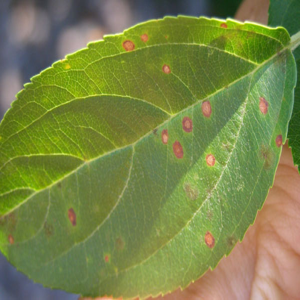

YOLO 병반 탐지 여부: True
YOLO 최고 confidence: 0.0688

ConvNeXt 전체 이미지 분류 Top5:
Top1: Apple___Apple_scab / conf=0.8171
Top2: Peach___Bacterial_spot / conf=0.1259
Top3: Pepper,_bell___Bacterial_spot / conf=0.0117
Top4: Apple___healthy / conf=0.0106
Top5: Cherry_(including_sour)___healthy / conf=0.0102

최종 판단: 병반 탐지됨 → ConvNeXt 질병 분류 결과 사용

####################################################################################################
selected_crop: Apple
이미지: 사과삼나무사과녹병1.jpg


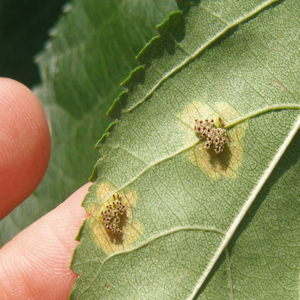

YOLO 병반 탐지 여부: True
YOLO 최고 confidence: 0.0836

ConvNeXt 전체 이미지 분류 Top5:
Top1: Grape___Black_rot / conf=0.9715
Top2: Apple___Cedar_apple_rust / conf=0.0113
Top3: Grape___Leaf_blight_(Isariopsis_Leaf_Spot) / conf=0.0032
Top4: Peach___Bacterial_spot / conf=0.0030
Top5: Corn_(maize)___Northern_Leaf_Blight / conf=0.0021

최종 판단: 병반 탐지됨 → ConvNeXt 질병 분류 결과 사용

####################################################################################################
selected_crop: Apple
이미지: 사과삼나무사과녹병2.jpg


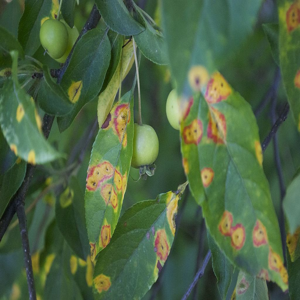

YOLO 병반 탐지 여부: True
YOLO 최고 confidence: 0.0224

ConvNeXt 전체 이미지 분류 Top5:
Top1: Pepper,_bell___Bacterial_spot / conf=0.5301
Top2: Corn_(maize)___Northern_Leaf_Blight / conf=0.1813
Top3: Apple___Black_rot / conf=0.1543
Top4: Peach___Bacterial_spot / conf=0.0643
Top5: Apple___Cedar_apple_rust / conf=0.0475

최종 판단: 병반 탐지됨 → ConvNeXt 질병 분류 결과 사용

####################################################################################################
selected_crop: Corn_(maize)
이미지: 옥수수북부잎마름병1.jpg


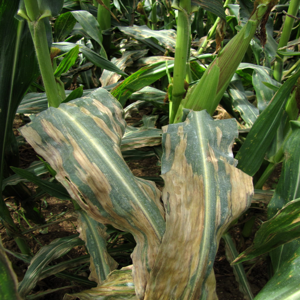

YOLO 병반 탐지 여부: True
YOLO 최고 confidence: 0.0267

ConvNeXt 전체 이미지 분류 Top5:
Top1: Corn_(maize)___Common_rust_ / conf=0.9748
Top2: Corn_(maize)___Northern_Leaf_Blight / conf=0.0252
Top3: Tomato___Leaf_Mold / conf=0.0000
Top4: Apple___Cedar_apple_rust / conf=0.0000
Top5: Peach___Bacterial_spot / conf=0.0000

최종 판단: 병반 탐지됨 → ConvNeXt 질병 분류 결과 사용

####################################################################################################
selected_crop: Corn_(maize)
이미지: 옥수수세르코스포라잎반점병2.jpg


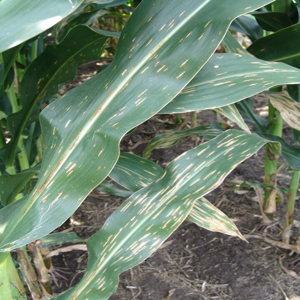

YOLO 병반 탐지 여부: False
YOLO 최고 confidence: 0.0000

ConvNeXt 전체 이미지 분류 Top5:
Top1: Corn_(maize)___Common_rust_ / conf=0.6008
Top2: Corn_(maize)___Northern_Leaf_Blight / conf=0.3966
Top3: Corn_(maize)___healthy / conf=0.0008
Top4: Cherry_(including_sour)___healthy / conf=0.0006
Top5: Peach___Bacterial_spot / conf=0.0005

최종 판단: 병반 미탐지 + ConvNeXt disease 예측 → 판단 어려움

####################################################################################################
selected_crop: Tomato
이미지: 토마토건강1.jpg


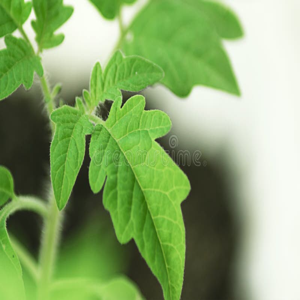

YOLO 병반 탐지 여부: False
YOLO 최고 confidence: 0.0000

ConvNeXt 전체 이미지 분류 Top5:
Top1: Tomato___Late_blight / conf=0.7056
Top2: Tomato___healthy / conf=0.2089
Top3: Tomato___Target_Spot / conf=0.0592
Top4: Pepper,_bell___healthy / conf=0.0101
Top5: Corn_(maize)___healthy / conf=0.0099

최종 판단: 병반 미탐지 + ConvNeXt disease 예측 → 판단 어려움

####################################################################################################
selected_crop: Tomato
이미지: 토마토건강2.jpg


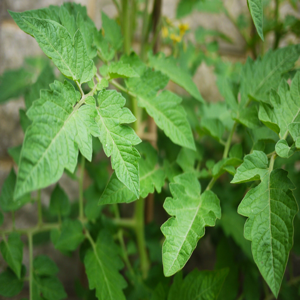

YOLO 병반 탐지 여부: False
YOLO 최고 confidence: 0.0000

ConvNeXt 전체 이미지 분류 Top5:
Top1: Potato___healthy / conf=0.5800
Top2: Apple___Apple_scab / conf=0.1463
Top3: Apple___Cedar_apple_rust / conf=0.1081
Top4: Tomato___Target_Spot / conf=0.0829
Top5: Apple___healthy / conf=0.0223

최종 판단: 병반 미탐지 + ConvNeXt healthy → 건강 가능성 높음

####################################################################################################
selected_crop: Tomato
이미지: 토마토전기역병1.jpg


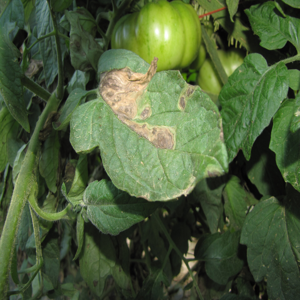

YOLO 병반 탐지 여부: True
YOLO 최고 confidence: 0.1214

ConvNeXt 전체 이미지 분류 Top5:
Top1: Potato___Late_blight / conf=0.6518
Top2: Tomato___Late_blight / conf=0.1370
Top3: Apple___Black_rot / conf=0.0736
Top4: Apple___Cedar_apple_rust / conf=0.0590
Top5: Tomato___healthy / conf=0.0161

최종 판단: 병반 탐지됨 → ConvNeXt 질병 분류 결과 사용

####################################################################################################
selected_crop: Tomato
이미지: 토마토점무늬병1.jpg


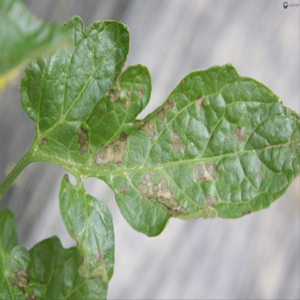

YOLO 병반 탐지 여부: True
YOLO 최고 confidence: 0.0360

ConvNeXt 전체 이미지 분류 Top5:
Top1: Apple___Apple_scab / conf=0.9288
Top2: Grape___Black_rot / conf=0.0289
Top3: Peach___Bacterial_spot / conf=0.0098
Top4: Tomato___Early_blight / conf=0.0066
Top5: Tomato___Target_Spot / conf=0.0040

최종 판단: 병반 탐지됨 → ConvNeXt 질병 분류 결과 사용

####################################################################################################
selected_crop: Tomato
이미지: 토마토점무늬병2.webp


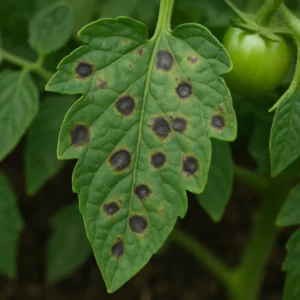

YOLO 병반 탐지 여부: False
YOLO 최고 confidence: 0.0000

ConvNeXt 전체 이미지 분류 Top5:
Top1: Tomato___Late_blight / conf=0.6468
Top2: Tomato___healthy / conf=0.1659
Top3: Tomato___Early_blight / conf=0.0820
Top4: Tomato___Septoria_leaf_spot / conf=0.0499
Top5: Cherry_(including_sour)___Powdery_mildew / conf=0.0323

최종 판단: 병반 미탐지 + ConvNeXt disease 예측 → 판단 어려움

####################################################################################################
selected_crop: Grape
이미지: 포도건강1.jpg


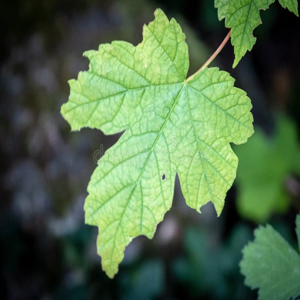

YOLO 병반 탐지 여부: False
YOLO 최고 confidence: 0.0000

ConvNeXt 전체 이미지 분류 Top5:
Top1: Tomato___Leaf_Mold / conf=0.8327
Top2: Grape___healthy / conf=0.1156
Top3: Tomato___Septoria_leaf_spot / conf=0.0199
Top4: Tomato___healthy / conf=0.0103
Top5: Tomato___Late_blight / conf=0.0072

최종 판단: 병반 미탐지 + ConvNeXt disease 예측 → 판단 어려움

####################################################################################################
selected_crop: Grape
이미지: 포도잎마름병1.jpg


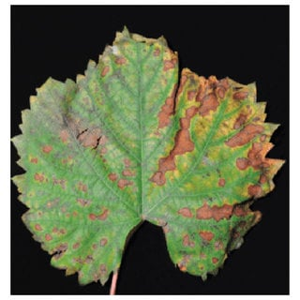

YOLO 병반 탐지 여부: False
YOLO 최고 confidence: 0.0000

ConvNeXt 전체 이미지 분류 Top5:
Top1: Tomato___Septoria_leaf_spot / conf=0.9262
Top2: Apple___Cedar_apple_rust / conf=0.0253
Top3: Raspberry___healthy / conf=0.0247
Top4: Tomato___Tomato_mosaic_virus / conf=0.0231
Top5: Grape___Leaf_blight_(Isariopsis_Leaf_Spot) / conf=0.0003

최종 판단: 병반 미탐지 + ConvNeXt disease 예측 → 판단 어려움


In [44]:
# ============================================================
# 6-9. 일괄 실행
# ============================================================

all_results = []

for item in ambiguous_tests:
    img_path = item["img_path"]
    selected_crop = item["selected_crop"]

    print("\n" + "#" * 100)
    print("selected_crop:", selected_crop)

    result = predict_reaf_mode_a(img_path, show=True)
    result["selected_crop"] = selected_crop

    all_results.append(result)

In [41]:
# ============================================================
# YOLO raw detection 디버깅
# conf를 매우 낮춰서 실제 박스 후보 확인
# ============================================================

from pathlib import Path
from PIL import Image
from IPython.display import display

DEBUG_CONF = 0.001

for item in ambiguous_tests:
    img_path = Path(item["img_path"])

    results = yolo_model.predict(
        source=str(img_path),
        conf=DEBUG_CONF,
        imgsz=640,
        verbose=False
    )

    boxes = results[0].boxes

    print("=" * 100)
    print("이미지:", img_path.name)

    if boxes is None or len(boxes) == 0:
        print("박스 후보 없음")
        continue

    confs = boxes.conf.cpu().numpy()
    print("박스 후보 수:", len(confs))
    print("최고 conf:", confs.max())
    print("상위 conf:", sorted(confs, reverse=True)[:10])

이미지: 사과검은썩음병1.jpg
박스 후보 수: 43
최고 conf: 0.06879317
상위 conf: [np.float32(0.06879317), np.float32(0.014483282), np.float32(0.0074869674), np.float32(0.006161434), np.float32(0.0047953557), np.float32(0.0036093195), np.float32(0.0035604446), np.float32(0.0034173506), np.float32(0.0031461723), np.float32(0.0027462088)]
이미지: 사과삼나무사과녹병1.jpg
박스 후보 수: 24
최고 conf: 0.08359951
상위 conf: [np.float32(0.08359951), np.float32(0.011831459), np.float32(0.004643203), np.float32(0.0043111006), np.float32(0.0038218938), np.float32(0.0036855235), np.float32(0.0034052844), np.float32(0.003079141), np.float32(0.0027232948), np.float32(0.0026988483)]
이미지: 사과삼나무사과녹병2.jpg
박스 후보 수: 35
최고 conf: 0.022390882
상위 conf: [np.float32(0.022390882), np.float32(0.019550612), np.float32(0.017756488), np.float32(0.012430808), np.float32(0.010997212), np.float32(0.010536625), np.float32(0.009391689), np.float32(0.007950072), np.float32(0.0047867866), np.float32(0.0039193598)]
이미지: 옥수수북부잎마름병1.jpg
박스 후보 수: 10
최고 conf: 0.026650218

In [42]:
# ============================================================
# YOLO 예측 박스 시각화 저장
# ============================================================

SAVE_DEBUG_DIR = Path("/home/harry/Re_leaf_Project/yolo_debug_ambiguous")
SAVE_DEBUG_DIR.mkdir(parents=True, exist_ok=True)

for item in ambiguous_tests:
    img_path = Path(item["img_path"])

    results = yolo_model.predict(
        source=str(img_path),
        conf=0.001,
        imgsz=640,
        save=True,
        project=str(SAVE_DEBUG_DIR),
        name="pred_boxes",
        exist_ok=True,
        verbose=False
    )

print("디버그 이미지 저장 완료:")
print(SAVE_DEBUG_DIR / "pred_boxes")

Results saved to /home/harry/Re_leaf_Project/yolo_debug_ambiguous/pred_boxes
Results saved to /home/harry/Re_leaf_Project/yolo_debug_ambiguous/pred_boxes
Results saved to /home/harry/Re_leaf_Project/yolo_debug_ambiguous/pred_boxes
Results saved to /home/harry/Re_leaf_Project/yolo_debug_ambiguous/pred_boxes
Results saved to /home/harry/Re_leaf_Project/yolo_debug_ambiguous/pred_boxes
Results saved to /home/harry/Re_leaf_Project/yolo_debug_ambiguous/pred_boxes
Results saved to /home/harry/Re_leaf_Project/yolo_debug_ambiguous/pred_boxes
Results saved to /home/harry/Re_leaf_Project/yolo_debug_ambiguous/pred_boxes
Results saved to /home/harry/Re_leaf_Project/yolo_debug_ambiguous/pred_boxes
Results saved to /home/harry/Re_leaf_Project/yolo_debug_ambiguous/pred_boxes
Results saved to /home/harry/Re_leaf_Project/yolo_debug_ambiguous/pred_boxes
Results saved to /home/harry/Re_leaf_Project/yolo_debug_ambiguous/pred_boxes
디버그 이미지 저장 완료:
/home/harry/Re_leaf_Project/yolo_debug_ambiguous/pred_boxes
